## Import necessary modules

In [30]:
from monitor_models import MonitorNet
import torch
import numpy as np
import pickle
from tqdm import tqdm
import random
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots, show
import os

## Set paths - This is the only cell that needs to be changed per user according to paths on their device

In [31]:
# set according to your paths

pred_pkl_path = '/home/ns38942/VERITAS/Monitor/results/preds_Channel_Profile.pkl'

## Read predictions

In [32]:
with open (pred_pkl_path, 'rb') as handle:
    content = pickle.load(handle)

pred_dict = content['pred_dict']
pred_dict_id = content['pred_dict_id']

## Plot test set clusters

  0%|                                                                                                                                                                                                           | 0/3 [00:00<?, ?it/s]

(2988, 256)


 33%|█████████████████████████████████████████████████████████████████                                                                                                                                  | 1/3 [00:02<00:04,  2.48s/it]

(2988, 256)


 67%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                 | 2/3 [00:04<00:02,  2.41s/it]

(2988, 256)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:07<00:00,  2.46s/it]


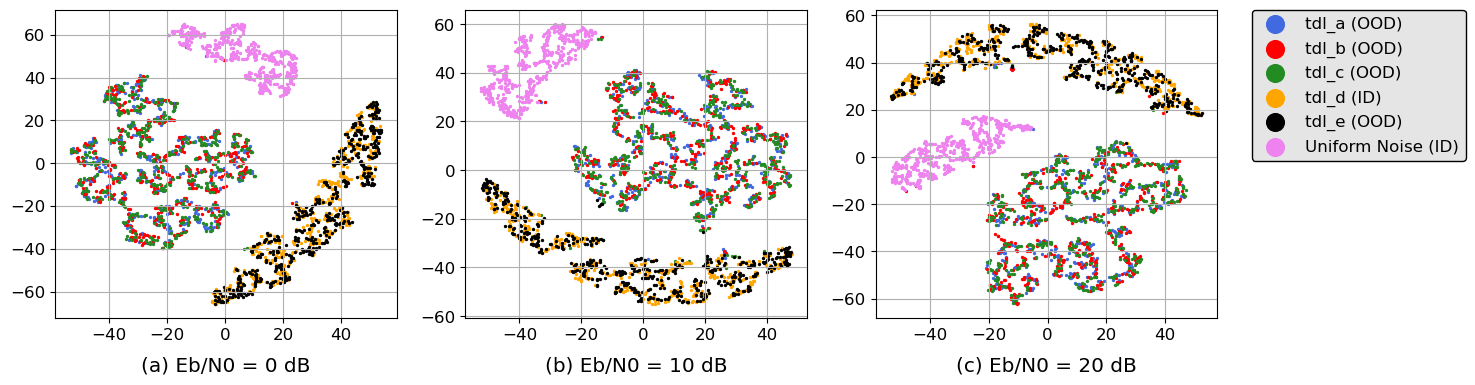

In [33]:
## read the prediction dictionary and study the ultimate layer features
## perform tsne

feature_dim = 256

speed = 10
SNR_range = [0,10,20]
channel_profiles = ['tdl_a','tdl_b','tdl_c','tdl_d','tdl_e','uniform']

color_list = ['royalblue','red','ForestGreen','orange','black','violet', 'cyan','gray','yellow','salmon','pink']

plt.rcParams['axes.titley'] = -0.2    # y is in axes-relative coordinates.
fig, axes = plt.subplots(figsize=(15,4), nrows=1, ncols=3)
matplotlib.rcParams.update({'font.size': 12})


for i in tqdm(range(len(SNR_range))): # because we have 3 SNRs and want 3 subplots
    SNR = SNR_range[i]
    ax = axes[i]
    all_classes_array = np.empty(shape=[0, feature_dim])
    stride_list = []
    
    for channel in channel_profiles:
        this_class_array = np.squeeze(np.array(pred_dict[channel][speed][SNR]))
        stride_list.append(this_class_array.shape[0])
        all_classes_array = np.concatenate((all_classes_array, this_class_array), axis=0)
    
    X = all_classes_array
    print(X.shape)
        
    
    """for tsne """    
    t_sne = TSNE(n_components=2, init='random')
    X_embedded= t_sne.fit_transform(X)
    
    x1 = X_embedded[:stride_list[0],0]
    y1 = X_embedded[:stride_list[0],1]
    start = stride_list[0]
    x2 = X_embedded[start:start+stride_list[1],0]
    y2 = X_embedded[start:start+stride_list[1],1]
    start+= stride_list[1]
    x3 = X_embedded[start:start+stride_list[2],0]
    y3 = X_embedded[start:start+stride_list[2],1]
    start+= stride_list[2]
    x4 = X_embedded[start:start+stride_list[3],0]
    y4 = X_embedded[start:start+stride_list[3],1]
    start+= stride_list[3]
    x5 = X_embedded[start:start+stride_list[4],0]
    y5 = X_embedded[start:start+stride_list[4],1]
    start+= stride_list[4]
    x6 = X_embedded[start:start+stride_list[5],0]
    y6 = X_embedded[start:start+stride_list[5],1]
    
    ax.scatter(x1, y1,s=2, linewidths=1, color=color_list[0], marker='o', label='tdl_a (OOD)') 
    ax.scatter(x2, y2,s=2, linewidths=1, color=color_list[1], marker='o', label='tdl_b (OOD)')  
    ax.scatter(x3, y3,s=2, linewidths=1, color=color_list[2], marker='o', label='tdl_c (OOD)')
    ax.scatter(x4, y4,s=2, linewidths=1, color=color_list[3], marker='o', label='tdl_d (ID)')
    ax.scatter(x5, y5,s=2, linewidths=1, color=color_list[4], marker='o', label='tdl_e (OOD)')
    ax.scatter(x6, y6,s=2, linewidths=1, color=color_list[5], marker='o', label='Uniform Noise (ID)')
    
    ax.grid()
    
    if i == len(SNR_range)-1:  # this is the last subplot, we need to insert legend
        legend = plt.legend(bbox_to_anchor=(1.1, 1), loc='upper left', borderaxespad=0, markerscale=9, edgecolor='black')
        legend.get_frame().set_alpha(None)
        legend.get_frame().set_facecolor((0, 0, 0, 0.1))


axes[0].title.set_text('(a) Eb/N0 = 0 dB') 
axes[1].title.set_text('(b) Eb/N0 = 10 dB') 
axes[2].title.set_text('(c) Eb/N0 = 20 dB')

plt.savefig('foo.pdf', bbox_inches='tight')

## Run the OOD detection algorithm and calculate OOD detection rate

In [34]:
lambda_val = 0.95

k_neighbors = [5,10,15]
feature_dim = 256
print(feature_dim)
           
def distance_function(a,b):
    a = np.squeeze(a)
    b = np.squeeze(b)
    distance = np.linalg.norm(a-b)    
    return distance


ood_dict = {}

SNR_range = list(np.arange(0,21,step=2))
print(SNR_range)
                 

speed = 10
    
for k_neighbor in k_neighbors:
    
    All_SNR_accuracies = []

    for i in tqdm(range(len(SNR_range))): 
        channel_models = ['tdl_d','uniform']  # training channel models
        
        SNR = SNR_range[i]
        all_classes_array = np.empty(shape=[0, feature_dim])
        all_classes_y = np.empty(shape=[0])
        train_set_stride_list = []
        
        for class_index,channel in enumerate(channel_models):
            this_class_array = np.squeeze(np.array(pred_dict_id[channel][speed][SNR]))
            this_class_y = np.ones((this_class_array.shape[0]))*(class_index)
            train_set_stride_list.append(this_class_array.shape[0])
            all_classes_y = np.concatenate((all_classes_y, this_class_y), axis=0)
            all_classes_array = np.concatenate((all_classes_array, this_class_array), axis=0)
        
        X_train = all_classes_array
        y_train = all_classes_y
    
    
        knn = NearestNeighbors(n_neighbors=k_neighbor, metric='euclidean', algorithm='ball_tree')
        knn.fit(X_train, y_train)
    
        
        start = 0 
        center_list, max_distance_list = [], []
        for i in range(len(channel_models)):
            # for each in distribution class
            this_X_train = X_train[start:start+train_set_stride_list[i]]
            start += train_set_stride_list[i]
            this_center = np.mean(this_X_train, axis=0)
            center_list.append(this_center)
            distance_list = []
            for X in this_X_train:
                distance_list.append(distance_function(X,this_center))
                
            # now find the max distance as the distance where 95% of samples are calculated as ID
            distance_list.sort()
            distance_list = distance_list[:int(lambda_val*len(distance_list))]
            max_distance_list.append(np.max(distance_list))
            
        # Now the center of all clusters are ready in center_list
        # and max distance for each cluster is also determined
    
        # go through the test set and for each sample find the nearest neighbors
        all_classes_array = np.empty(shape=[0, feature_dim])
        stride_list = []
    
        channel_models = ['tdl_a','tdl_b','tdl_c','tdl_d','tdl_e','uniform']   # test channel models
        this_SNR_accuracies = []
        for class_index,channel in enumerate(channel_models):           
            
            X_test = np.array(pred_dict[channel][speed][SNR])
            ood_counter = 0
            for X in X_test:
                #print(X.shape)
                # find the k nearest neighbors:
                knn_prediction = knn.kneighbors(X)
                neighbor_distances = list(np.squeeze(knn_prediction[0]))
                neighbor_indexes = list(np.squeeze(knn_prediction[1]))
                
                ood_decision = []
                class_list_for_this_X = []
                for neighbor_index, neighbor_distance in zip(neighbor_indexes, neighbor_distances):
                    
                    this_neighbor = X_train[neighbor_index]
                    this_neighbor_class = int(y_train[neighbor_index])
                    
                    this_neighbor_distance_from_cluster_center = distance_function(this_neighbor , center_list[this_neighbor_class])
                    this_X_distance_from_cluster_center = distance_function(X , center_list[this_neighbor_class])
                    this_cluster_max_distance = max_distance_list[this_neighbor_class]
                    
                    if this_X_distance_from_cluster_center <= this_neighbor_distance_from_cluster_center and this_X_distance_from_cluster_center < this_cluster_max_distance:
                        ood_decision.append('ID')
                        class_list_for_this_X.append(this_neighbor_class)
                    else:
                        ood_decision.append('OOD')
                
                if 'ID' not in ood_decision:
                    ood_counter += 1
    
    
            # now we have ood_counter for all the samples in the test class, get accuracy
            this_SNR_accuracies.append(ood_counter/X_test.shape[0])
        
        All_SNR_accuracies.append(this_SNR_accuracies)
    
    for i,channel in enumerate(channel_models):
        if channel not in ood_dict:
            ood_dict[channel] = {}
            
        this_list = []
        for j in range(len(SNR_range)):
            this_list.append(round(All_SNR_accuracies[j][i],4))
        
        ood_dict[channel][k_neighbor] = this_list
        # print(this_list)
    # print('-----------------------')

256
[np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(20)]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:23<00:00,  2.15s/it]


## plotting ood detection rate

[np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(20)]
Channel: tdl_a
0.9872363636363637 0.9819272727272729 0.9786363636363636
Channel: tdl_b
0.9848545454545455 0.9801090909090909 0.9768272727272727
Channel: tdl_c
0.9771636363636363 0.970790909090909 0.9671363636363637
Channel: tdl_d
0.08708181818181819 0.05350000000000001 0.051854545454545466
Channel: tdl_e
0.09310000000000002 0.06023636363636365 0.05805454545454547
Channel: uniform
0.09364545454545457 0.054936363636363644 0.05238181818181819
(6,)
6
3


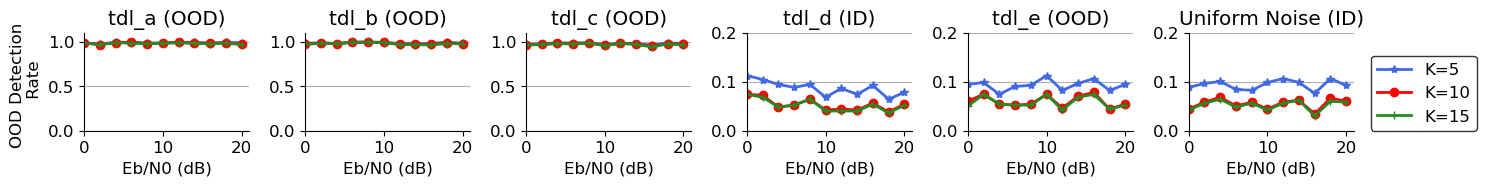

In [35]:
## plotting ood detection rate

x = list(np.arange(21, step=2))
print(x)
y = []

channel_models = ['tdl_a','tdl_b','tdl_c','tdl_d','tdl_e','uniform']   # test channel models
for channel in channel_models:
    a = ood_dict[channel][5]
    b = ood_dict[channel][10]
    c = ood_dict[channel][15]
    
    y.append([a,b,c])
    print('Channel: '+channel)
    print(sum(a)/len(a),sum(b)/len(b),sum(c)/len(c))      
  
color_list = ['royalblue','red','ForestGreen','orange','black','violet', 'cyan','gray','yellow','salmon','pink']
legends = ['K=5','K=10','K=15']
markers = ['*','o','+','x']
titles = ['tdl_a (OOD)','tdl_b (OOD)','tdl_c (OOD)','tdl_d (ID)','tdl_e (OOD)','Uniform Noise (ID)']
y_limits = [[0,1.1],[0,1.1],[0,1.1],[0,0.2],[0,0.2],[0,0.2]]
y_tick_list = [[0,0.5,1],[0,0.5,1],[0,0.5,1],[0,0.1,0.2],[0,0.1,0.2],[0,0.1,0.2]]


plt.rcParams['axes.titley'] = 1    # y is in axes-relative coordinates.
matplotlib.rcParams.update({'font.size': 12})
fig, axes = subplots(figsize=(15,2), nrows=1, ncols=len(y))

print(axes.shape)
print(len(y))
print(len(y[0]))

for i in range(len(y)):
    this_y = y[i]
    ax = axes[i]
    ax.spines[['right', 'top']].set_visible(False)
    for j in range(len(this_y)):
        this_line = this_y[j]
        ax.plot(x, this_line, linewidth=2, color=color_list[j], label=legends[j], marker=markers[j])
    ax.set_ylim(y_limits[i])
    ax.set_xlim([0,21])
    ax.set_xticks([0,10,20])
    ax.set_yticks(y_tick_list[i])
    ax.set_xlabel('Eb/N0 (dB)')
    ax.set_title(titles[i])
    ax.yaxis.grid()
    # put y lable just for fist plot
    if i == 0:
        ax.set_ylabel('OOD Detection \n Rate')
    # put legend just for last subplot
    if i == len(y)-1:
        ax.legend(loc='lower left',bbox_to_anchor=(1.1, 0), ncol=1, borderaxespad=0, edgecolor='black')

fig.tight_layout(pad=1.0)
plt.savefig('foo.pdf', bbox_inches='tight')



## Keep lambda as 0.95 and vary K from 3 to 19 for SNR = 0, 10, 20

In [44]:
lambda_val = 0.95

k_neighbors = [3,5,7,9,11,13,15,17,19]
feature_dim = 256
print(feature_dim)

def distance_function(a,b):
    a = np.squeeze(a)
    b = np.squeeze(b)
    distance = np.linalg.norm(a-b)    
    return distance


ood_dict = {}

SNR_range = [0,10,20]
print(SNR_range)
                 
          
def distance_function(a,b):
    a = np.squeeze(a)
    b = np.squeeze(b)
    distance = np.linalg.norm(a-b)    
    return distance


ood_dict = {}

SNR_range = list(np.arange(0,21,step=2))
print(SNR_range)
                 

speed = 10
    
for k_neighbor in k_neighbors:
    
    All_SNR_accuracies = []

    for i in tqdm(range(len(SNR_range))): 
        channel_models = ['tdl_d','uniform']  # training channel models
        
        SNR = SNR_range[i]
        all_classes_array = np.empty(shape=[0, feature_dim])
        all_classes_y = np.empty(shape=[0])
        train_set_stride_list = []
        
        for class_index,channel in enumerate(channel_models):
            this_class_array = np.squeeze(np.array(pred_dict_id[channel][speed][SNR]))
            this_class_y = np.ones((this_class_array.shape[0]))*(class_index)
            train_set_stride_list.append(this_class_array.shape[0])
            all_classes_y = np.concatenate((all_classes_y, this_class_y), axis=0)
            all_classes_array = np.concatenate((all_classes_array, this_class_array), axis=0)
        
        X_train = all_classes_array
        y_train = all_classes_y
    
    
        knn = NearestNeighbors(n_neighbors=k_neighbor, metric='euclidean', algorithm='ball_tree')
        knn.fit(X_train, y_train)
    
        
        start = 0 
        center_list, max_distance_list = [], []
        for i in range(len(channel_models)):
            # for each in distribution class
            this_X_train = X_train[start:start+train_set_stride_list[i]]
            start += train_set_stride_list[i]
            this_center = np.mean(this_X_train, axis=0)
            center_list.append(this_center)
            distance_list = []
            for X in this_X_train:
                distance_list.append(distance_function(X,this_center))
                
            # now find the max distance as the distance where 95% of samples are calculated as ID
            distance_list.sort()
            distance_list = distance_list[:int(lambda_val*len(distance_list))]
            max_distance_list.append(np.max(distance_list))
            
        # Now the center of all clusters are ready in center_list
        # and max distance for each cluster is also determined
    
        # go through the test set and for each sample find the nearest neighbors
        all_classes_array = np.empty(shape=[0, feature_dim])
        stride_list = []
    
        channel_models = ['tdl_a','tdl_b','tdl_c','tdl_d','tdl_e','uniform']   # test channel models
        this_SNR_accuracies = []
        for class_index,channel in enumerate(channel_models):           
            
            X_test = np.array(pred_dict[channel][speed][SNR])
            ood_counter = 0
            for X in X_test:
                #print(X.shape)
                # find the k nearest neighbors:
                knn_prediction = knn.kneighbors(X)
                neighbor_distances = list(np.squeeze(knn_prediction[0]))
                neighbor_indexes = list(np.squeeze(knn_prediction[1]))
                
                ood_decision = []
                class_list_for_this_X = []
                for neighbor_index, neighbor_distance in zip(neighbor_indexes, neighbor_distances):
                    
                    this_neighbor = X_train[neighbor_index]
                    this_neighbor_class = int(y_train[neighbor_index])
                    
                    this_neighbor_distance_from_cluster_center = distance_function(this_neighbor , center_list[this_neighbor_class])
                    this_X_distance_from_cluster_center = distance_function(X , center_list[this_neighbor_class])
                    this_cluster_max_distance = max_distance_list[this_neighbor_class]
                    
                    if this_X_distance_from_cluster_center <= this_neighbor_distance_from_cluster_center and this_X_distance_from_cluster_center < this_cluster_max_distance:
                        ood_decision.append('ID')
                        class_list_for_this_X.append(this_neighbor_class)
                    else:
                        ood_decision.append('OOD')
                
                if 'ID' not in ood_decision:
                    ood_counter += 1
    
    
            # now we have ood_counter for all the samples in the test class, get accuracy
            this_SNR_accuracies.append(ood_counter/X_test.shape[0])
        
        All_SNR_accuracies.append(this_SNR_accuracies)
    
    # For this specific k
    
    for i,channel in enumerate(channel_models):
        if channel not in ood_dict:
            ood_dict[channel] = {}

        for j in range(len(SNR_range)):
            if SNR_range[j] not in ood_dict[channel]:
                ood_dict[channel][SNR_range[j]] = []
            ood_dict[channel][SNR_range[j]].append(round(All_SNR_accuracies[j][i],4))
            
            
        
    # print('-----------------------')
# print(ood_dict)

256
[0, 10, 20]
[np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(20)]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:30<00:00,  2.81s/it]


9
[ 3  5  7  9 11 13 15 17 19]
[0.992, 0.988, 0.9859, 0.9859, 0.9859, 0.9839, 0.9819, 0.9799, 0.9799]
Channel: tdl_a
0.984811111111111 0.9830222222222221 0.9741333333333334
[0.9859, 0.9799, 0.9759, 0.9719, 0.9719, 0.9719, 0.9699, 0.9679, 0.9679]
Channel: tdl_b
0.9736777777777778 0.9895444444444443 0.9781333333333334
[0.9719, 0.9679, 0.9659, 0.9659, 0.9639, 0.9639, 0.9598, 0.9578, 0.9578]
Channel: tdl_c
0.9638666666666666 0.9591666666666667 0.9700888888888889
[0.1948, 0.1124, 0.0823, 0.0763, 0.0743, 0.0743, 0.0743, 0.0743, 0.0743]
Channel: tdl_d
0.09303333333333336 0.06026666666666668 0.07205555555555558
[0.1807, 0.0944, 0.0703, 0.0622, 0.0562, 0.0502, 0.0502, 0.0502, 0.0502]
Channel: tdl_e
0.07384444444444445 0.0972777777777778 0.07205555555555557
[0.2028, 0.0884, 0.0482, 0.0442, 0.0442, 0.0442, 0.0422, 0.0422, 0.0422]
Channel: uniform
0.06651111111111113 0.06561111111111112 0.07941111111111113
(6,)
6
3


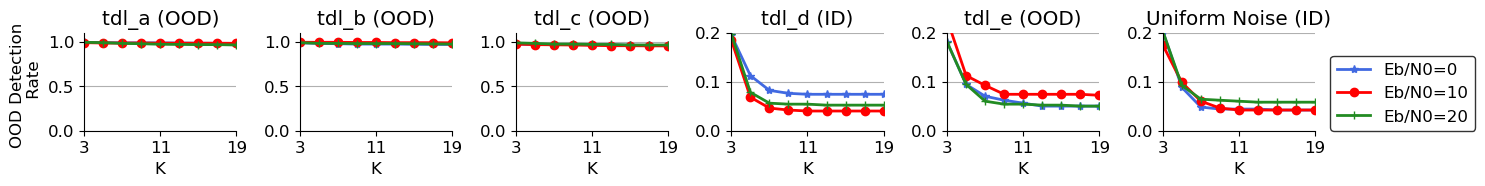

In [45]:
## plotting ood detection rate

print(len(k_neighbors))
x = np.arange(k_neighbors[-1]-1,step=2) + k_neighbors[0]

print(x)
y = []

channel_models = ['tdl_a','tdl_b','tdl_c','tdl_d','tdl_e','uniform']   # test channel models
for channel in channel_models:
    a = ood_dict[channel][0]
    b = ood_dict[channel][10]
    c = ood_dict[channel][20]

    print(a)
    
    y.append([a,b,c])
    print('Channel: '+channel)
    print(sum(a)/len(a),sum(b)/len(b),sum(c)/len(c))      
  
color_list = ['royalblue','red','ForestGreen','orange','black','violet', 'cyan','gray','yellow','salmon','pink']
legends = ['Eb/N0=0','Eb/N0=10','Eb/N0=20']
markers = ['*','o','+','x']
titles = ['tdl_a (OOD)','tdl_b (OOD)','tdl_c (OOD)','tdl_d (ID)','tdl_e (OOD)','Uniform Noise (ID)']
y_limits = [[0,1.1],[0,1.1],[0,1.1],[0,0.2],[0,0.2],[0,0.2]]
y_tick_list = [[0,0.5,1],[0,0.5,1],[0,0.5,1],[0,0.1,0.2],[0,0.1,0.2],[0,0.1,0.2]]

plt.rcParams['axes.titley'] = 1    # y is in axes-relative coordinates.
matplotlib.rcParams.update({'font.size': 12})
fig, axes = subplots(figsize=(15,2), nrows=1, ncols=len(y))

print(axes.shape)
print(len(y))
print(len(y[0]))

for i in range(len(y)):
    this_y = y[i]
    ax = axes[i]
    ax.spines[['right', 'top']].set_visible(False)
    for j in range(len(this_y)):
        this_line = this_y[j]
        ax.plot(x, this_line, linewidth=2, color=color_list[j], label=legends[j], marker=markers[j])
    ax.set_ylim(y_limits[i])
    ax.set_xlim([x[0],x[-1]])
    ax.set_xticks([x[0],(x[0]+x[-1])/2,x[-1]])
    ax.set_yticks(y_tick_list[i])
    ax.set_xlabel('K')
    ax.set_title(titles[i])
    ax.yaxis.grid()
    # put y lable just for fist plot
    if i == 0:
        ax.set_ylabel('OOD Detection \n Rate')
    # put legend just for last subplot
    if i == len(y)-1:
        ax.legend(loc='lower left',bbox_to_anchor=(1.1, 0), ncol=1, borderaxespad=0, edgecolor='black')

fig.tight_layout(pad=1.0)
plt.savefig('foo.pdf', bbox_inches='tight')

## Keep K = 15 and vary lambda = 0.5 to 1.0

In [40]:
lambda_vals = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

k_neighbor = 15
feature_dim = 256
print(feature_dim)

def distance_function(a,b):
    a = np.squeeze(a)
    b = np.squeeze(b)
    distance = np.linalg.norm(a-b)    
    return distance


ood_dict = {}

SNR_range = [0,10,20]
print(SNR_range)
                 
speed = 10

for lambda_val in lambda_vals:
    
    All_SNR_accuracies = []

    for i in tqdm(range(len(SNR_range))): 
        channel_models = ['tdl_d','uniform']  # training channel models
        
        SNR = SNR_range[i]
        all_classes_array = np.empty(shape=[0, feature_dim])
        all_classes_y = np.empty(shape=[0])
        train_set_stride_list = []
        
        for class_index,channel in enumerate(channel_models):
            this_class_array = np.squeeze(np.array(pred_dict_id[channel][speed][SNR]))
            this_class_y = np.ones((this_class_array.shape[0]))*(class_index)
            train_set_stride_list.append(this_class_array.shape[0])
            all_classes_y = np.concatenate((all_classes_y, this_class_y), axis=0)
            all_classes_array = np.concatenate((all_classes_array, this_class_array), axis=0)
        
        X_train = all_classes_array
        y_train = all_classes_y
    
    
        knn = NearestNeighbors(n_neighbors=k_neighbor, metric='euclidean', algorithm='ball_tree')
        knn.fit(X_train, y_train)
    
        
        start = 0 
        center_list, max_distance_list = [], []
        for i in range(len(channel_models)):
            # for each in distribution class
            this_X_train = X_train[start:start+train_set_stride_list[i]]
            start += train_set_stride_list[i]
            this_center = np.mean(this_X_train, axis=0)
            center_list.append(this_center)
            distance_list = []
            for X in this_X_train:
                distance_list.append(distance_function(X,this_center))
                
            # now find the max distance as the distance where 95% of samples are calculated as ID
            distance_list.sort()
            distance_list = distance_list[:int(lambda_val*len(distance_list))]
            max_distance_list.append(np.max(distance_list))
            
        # Now the center of all clusters are ready in center_list
        # and max distance for each cluster is also determined
    
        # go through the test set and for each sample find the nearest neighbors
        all_classes_array = np.empty(shape=[0, feature_dim])
        stride_list = []
    
        channel_models = ['tdl_a','tdl_b','tdl_c','tdl_d','tdl_e','uniform']   # test channel models
        this_SNR_accuracies = []
        for class_index,channel in enumerate(channel_models):           
            
            X_test = np.array(pred_dict[channel][speed][SNR])
            ood_counter = 0
            for X in X_test:
                #print(X.shape)
                # find the k nearest neighbors:
                knn_prediction = knn.kneighbors(X)
                neighbor_distances = list(np.squeeze(knn_prediction[0]))
                neighbor_indexes = list(np.squeeze(knn_prediction[1]))
                
                ood_decision = []
                class_list_for_this_X = []
                for neighbor_index, neighbor_distance in zip(neighbor_indexes, neighbor_distances):
                    
                    this_neighbor = X_train[neighbor_index]
                    this_neighbor_class = int(y_train[neighbor_index])
                    
                    this_neighbor_distance_from_cluster_center = distance_function(this_neighbor , center_list[this_neighbor_class])
                    this_X_distance_from_cluster_center = distance_function(X , center_list[this_neighbor_class])
                    this_cluster_max_distance = max_distance_list[this_neighbor_class]
                    
                    if this_X_distance_from_cluster_center <= this_neighbor_distance_from_cluster_center and this_X_distance_from_cluster_center < this_cluster_max_distance:
                        ood_decision.append('ID')
                        class_list_for_this_X.append(this_neighbor_class)
                    else:
                        ood_decision.append('OOD')
                
                if 'ID' not in ood_decision:
                    ood_counter += 1
    
    
            # now we have ood_counter for all the samples in the test class, get accuracy
            this_SNR_accuracies.append(ood_counter/X_test.shape[0])
        
        All_SNR_accuracies.append(this_SNR_accuracies)
    
   # For this specific lambda_val
    
    for i,channel in enumerate(channel_models):
        if channel not in ood_dict:
            ood_dict[channel] = {}

        for j in range(len(SNR_range)):
            if SNR_range[j] not in ood_dict[channel]:
                ood_dict[channel][SNR_range[j]] = []
            ood_dict[channel][SNR_range[j]].append(round(All_SNR_accuracies[j][i],4))
            
#print(ood_dict)

256
[0, 10, 20]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:06<00:00,  2.04s/it]


[0.5 0.6 0.7 0.8 0.9 1. ]
[0.996, 0.996, 0.992, 0.99, 0.988, 0.9739]
Channel: tdl_a
0.9893166666666667 0.9892833333333333 0.9775666666666666
[0.998, 0.996, 0.994, 0.994, 0.99, 0.9659]
Channel: tdl_b
0.9896500000000001 0.9933166666666667 0.9876166666666665
[0.996, 0.996, 0.992, 0.9819, 0.9759, 0.9578]
Channel: tdl_c
0.9832666666666666 0.96685 0.9782500000000001
[0.5, 0.3876, 0.2851, 0.1988, 0.1084, 0.0]
Channel: tdl_d
0.24665 0.25335 0.2955
[0.5361, 0.4337, 0.3313, 0.2088, 0.0904, 0.002]
Channel: tdl_e
0.26705 0.2824666666666667 0.23491666666666666
[0.498, 0.3876, 0.2791, 0.2108, 0.0823, 0.0]
Channel: uniform
0.24296666666666664 0.24966666666666668 0.2352666666666667
(6,)
6
3


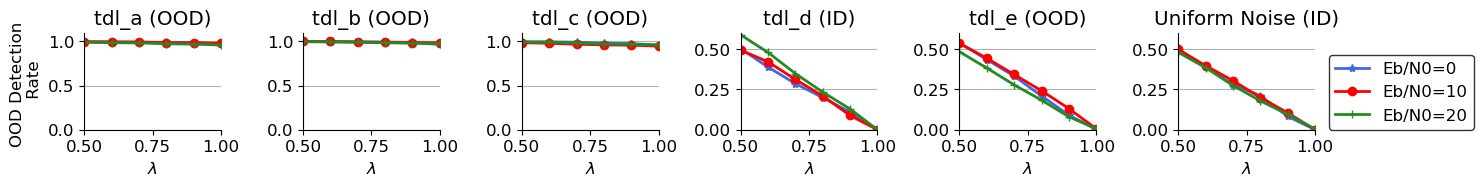

In [42]:
## plotting ood detection rate

x = np.array(lambda_vals)

print(x)
y = []

channel_models = ['tdl_a','tdl_b','tdl_c','tdl_d','tdl_e','uniform']   # test channel models
for channel in channel_models:
    a = ood_dict[channel][0]
    b = ood_dict[channel][10]
    c = ood_dict[channel][20]

    print(a)
    
    y.append([a,b,c])
    print('Channel: '+channel)
    print(sum(a)/len(a),sum(b)/len(b),sum(c)/len(c))      
  
color_list = ['royalblue','red','ForestGreen','orange','black','violet', 'cyan','gray','yellow','salmon','pink']
legends = ['Eb/N0=0','Eb/N0=10','Eb/N0=20']
markers = ['*','o','+','x']
titles = ['tdl_a (OOD)','tdl_b (OOD)','tdl_c (OOD)','tdl_d (ID)','tdl_e (OOD)','Uniform Noise (ID)']
y_limits = [[0,1.1],[0,1.1],[0,1.1],[0,0.6],[0,0.6],[0,0.6]]
y_tick_list = [[0,0.5,1],[0,0.5,1],[0,0.5,1],[0,0.25,0.5],[0,0.25,0.5],[0,0.25,0.5]]

plt.rcParams['axes.titley'] = 1    # y is in axes-relative coordinates.
matplotlib.rcParams.update({'font.size': 12})
fig, axes = subplots(figsize=(15,2), nrows=1, ncols=len(y))

print(axes.shape)
print(len(y))
print(len(y[0]))


for i in range(len(y)):
    this_y = y[i]
    ax = axes[i]
    ax.spines[['right', 'top']].set_visible(False)
    for j in range(len(this_y)):
        this_line = this_y[j]
        ax.plot(x, this_line, linewidth=2, color=color_list[j], label=legends[j], marker=markers[j])
    ax.set_ylim(y_limits[i])
    ax.set_xlim([x[0],1.0])
    ax.set_xticks([x[0],0.75,x[-1]])
    ax.set_yticks(y_tick_list[i])
    ax.set_xlabel('$\lambda$')
    ax.set_title(titles[i])
    ax.yaxis.grid()
    # put y lable just for fist plot
    if i == 0:
        ax.set_ylabel('OOD Detection \n Rate')
    # put legend just for last subplot
    if i == len(y)-1:
        ax.legend(loc='lower left',bbox_to_anchor=(1.1, 0), ncol=1, borderaxespad=0, edgecolor='black')

fig.tight_layout(pad=1.0)
plt.savefig('foo.pdf', bbox_inches='tight')